In this notebook, we will show you the differents steps to train step by step dly your model in this competition.

# Images Extractions

In [1]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
# !wget -q  https://share.phys.ethz.ch/~pf/albecker/abc/09072022_1154_train.h5
# !mv 09072022_1154_train.h5 ./data/
# !wget -q  https://share.phys.ethz.ch/~pf/albecker/abc/09072022_1154_val.h5
# !mv 09072022_1154_val.h5 ./data/
# !wget -q https://share.phys.ethz.ch/~pf/albecker/abc/09072022_1154_test.h5
# !mv 09072022_1154_test.h5 ./data/

zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget


In [2]:
trainset = h5py.File("../drive/MyDrive/vscode-ssh/GIZ_Biomass/data/09072022_1154_train.h5", "r")
validateset = h5py.File("../drive/MyDrive/vscode-ssh/GIZ_Biomass/data/09072022_1154_val.h5", "r")
testset = h5py.File("../drive/MyDrive/vscode-ssh/GIZ_Biomass/data/09072022_1154_test.h5", "r")

In [3]:
# attributes of trainset
trainset.keys()

<KeysViewHDF5 ['agbd', 'cloud', 'images', 'lat', 'lon', 'scl']>

In [4]:
# attributes of trainset
testset.keys()

<KeysViewHDF5 ['agbd', 'cloud', 'images', 'lat', 'lon', 'scl']>

In [5]:
train_cloud = np.array(trainset['cloud'],dtype=np.float64)

In [6]:
train_cloud.shape

(25036, 15, 15, 1)

## Explore datasets

In [7]:
# train
train_images = np.array(trainset['images'],dtype=np.float64)
train_images = train_images.transpose(0,3,1,2)

train_biomasses = np.array(trainset['agbd'],dtype=np.float64)

# validate
validate_images = np.array(validateset['images'],dtype=np.float64)
validate_images = validate_images.transpose(0,3,1,2)
validate_biomasses = np.array(validateset['agbd'],dtype=np.float64)

# test 
test_images = np.array(testset['images'],dtype=np.float32)
test_images = test_images.transpose(0,3,1,2)
test_biomasses = np.array(testset['agbd'],dtype=np.float32)

In [8]:
print(f"train dataset size {train_images.shape} train lab size {train_biomasses.shape}")
print()
print(f"validate dataset size {validate_images.shape} validate lab size {validate_biomasses.shape}")
print()
print(f"test dataset size {test_images.shape} test lab size {test_biomasses.shape}")

train dataset size (25036, 12, 15, 15) train lab size (25036,)

validate dataset size (5174, 12, 15, 15) validate lab size (5174,)

test dataset size (5190, 12, 15, 15) test lab size (5190,)


##  Some visulizations

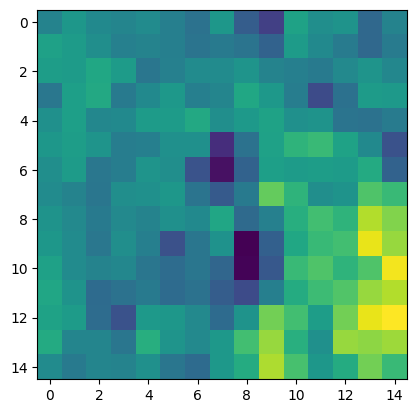

In [9]:
plt.imshow(train_images[1,1,:,:])

In [10]:
train_biomasses[1]

99.10187530517578

 **Below we explore the skewness of train dataset in each channel**

In [11]:
band_skewness = []
band_skewness_after_sqrt = []
for c in range(12):
    #calculate skewness
    band_skewness.append(pd.Series(train_images[:,c].flatten()).skew())
    #calculate skewness after applying sqrt
    band_skewness_after_sqrt.append(pd.Series(np.sqrt(train_images[:,c].flatten())).skew())

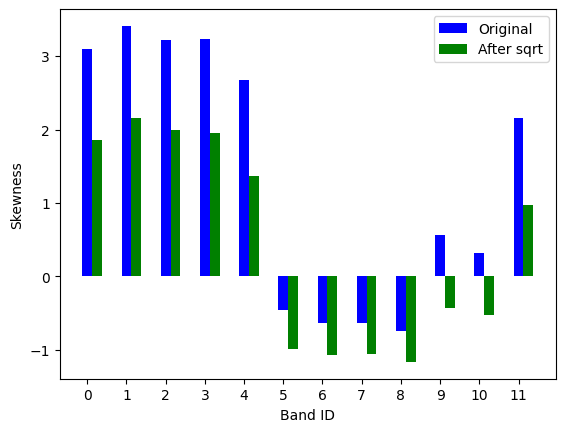

In [12]:
# skweness
width = 0.25

rng = [i for i in range(0,12)]
rng2 = [i+width for i in range(0,12)]

plt.bar(rng, band_skewness, align='center', width = width, label='Original', color ='b')
plt.bar(rng2, band_skewness_after_sqrt, align='center', width = width, label='After sqrt', color ='g')
plt.gca().set_xticks(rng)
plt.legend()
plt.xlabel('Band ID')
plt.ylabel('Skewness')
plt.show()

# Exploration approach

In [13]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso, ElasticNet
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [14]:
from sklearn import set_config
set_config(display='diagram')

## Pipeline of training

In [15]:
# constante for standardization
MEAN = train_images.mean((0,2,3))
STD = train_images.std((0,2,3))

In [16]:
class CustomScaler(BaseEstimator, TransformerMixin):
  def __init__(self,mean,std):
    self.mean = mean
    self.std = std
  
  def fit(self, X, y=None):
    #self.mean = X.mean((0,2,3)) 
    #self.std = X.std((0,2,3))
    return self

  def transform(self, X, y=None):
    return (X-self.mean[None,:,None,None])/self.std[None,:,None,None] 

  def reverse_transform(self):
    return None
    
class FlattenTransformer(BaseEstimator, TransformerMixin):

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    return X.reshape((X.shape[0], -1))

pipe = Pipeline(steps=[("scaler", CustomScaler(MEAN,STD)),
                       ("flatten", FlattenTransformer()),
                       ("classifier", Lasso())
])

In [17]:
pipe.fit(train_images,train_biomasses)

Pipeline(steps=[('scaler',
                 CustomScaler(mean=array([ 644.62522678,  675.00465197,  887.51322647,  649.01398076,
       1230.65511708, 3005.58275568, 3717.91194245, 3626.2871387 ,
       3999.28166498, 4109.51322682, 2262.52644121, 1253.58153468]),
                              std=array([ 575.97684675,  570.30180631,  536.11125314,  550.22417005,
        557.76750885,  777.03590322,  935.15224447,  949.36012986,
        988.61001558, 1096.67397739,  671.68692054,  590.6012704 ]))),
                ('flatten', FlattenTransformer()), ('classifier', Lasso())])

In [18]:
# predict
pred_train = pipe.predict(train_images)

# train mse error
mse = mean_squared_error(train_biomasses, pred_train) 
rmse = np.sqrt(mse)
rmse

54.98686484405351

In [19]:
# predict
pred_validate = pipe.predict(validate_images)

#  validate mse error
mse = mean_squared_error(validate_biomasses, pred_validate) 
rmse = np.sqrt(mse)
rmse

62.94396603055366

## Gridsearch

In [23]:
# Initiaze the hyperparameters for each dictionary
param1 = {}
param1['classifier'] = [LinearRegression()]

param2 = {}
param2['classifier__alpha'] = [0.1, 0.5, 1]
param2['classifier'] = [Ridge()]

param3 = {}
param3['classifier__alpha'] = [0.1, 0.5, 1]
param3['classifier'] = [Lasso()]

param4 = {}
param4['classifier__n_neighbors'] = [2,5,10,25,50]
param4['classifier'] = [KNeighborsRegressor()]

param5 = {}
param5['classifier__C'] = [10**-2, 10**-1, 10**0, 10**1, 10**2]
param5['classifier__epsilon'] = [0.0,0.2,0.5,1]
param5['classifier'] = [LinearSVR()]

param6 = {}
param6['classifier__alpha'] = [0.1, 0.5, 1]
param6['classifier'] = [ElasticNet()]

param7 = {}
param7['classifier__n_estimators'] = [50, 100, 200, 500]
param7['classifier'] = [RandomForestRegressor()]

param8 = {}
param8['classifier__learning_rate'] = [0.01, 0.02, 0.05, 0.1]
param7['classifier__n_estimators'] = [50, 100, 200, 500]
param8['classifier'] = [GradientBoostingRegressor()]


In [26]:
pipeline = pipe = Pipeline(steps=[("scaler", CustomScaler(MEAN,STD)),
                       ("flatten", FlattenTransformer()),
                       ("classifier", LinearRegression())])
# params = [param1, param2, param3, param4, param5, param6, param7, param8]
params = [param3]


In [27]:
# Train the grid search model
grid_search = GridSearchCV(pipeline, params, cv=3, scoring='neg_mean_squared_error', verbose=3).fit(train_images,train_biomasses)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3] END classifier=Lasso(), classifier__alpha=0.1;, score=-2998.152 total time=  40.1s
[CV 2/3] END classifier=Lasso(), classifier__alpha=0.1;, score=-2811.111 total time=  34.0s
[CV 3/3] END classifier=Lasso(), classifier__alpha=0.1;, score=-2773.588 total time=  32.7s
[CV 1/3] END classifier=Lasso(), classifier__alpha=0.5;, score=-3118.225 total time=  26.8s
[CV 2/3] END classifier=Lasso(), classifier__alpha=0.5;, score=-2914.758 total time=  26.4s
[CV 3/3] END classifier=Lasso(), classifier__alpha=0.5;, score=-2860.099 total time=  34.7s
[CV 1/3] END classifier=Lasso(), classifier__alpha=1;, score=-3192.474 total time=  21.7s
[CV 2/3] END classifier=Lasso(), classifier__alpha=1;, score=-2977.374 total time=  11.6s
[CV 3/3] END classifier=Lasso(), classifier__alpha=1;, score=-2928.358 total time=  17.9s


In [28]:
# Best performing model and its corresponding hyperparameters
grid_search.best_params_

{'classifier': Lasso(alpha=0.1), 'classifier__alpha': 0.1}

# Use Lasso regression as features selector

In [22]:
#   Params definitions
params_lasso = {
    # "classifier__alpha": [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1e-1, 1],
    "classifier__alpha": [1e-1],
    "classifier" : [Lasso()]
}

pipe = Pipeline(steps=[("scaler", CustomScaler(MEAN, STD)),
                       ("flatten", FlattenTransformer()),
                       ("classifier", Lasso())])
params = [params_lasso]

In [23]:
# Train the grid search model
grid_search = GridSearchCV(pipe, params_lasso, cv=3, scoring='neg_mean_squared_error', verbose=3).fit(train_images,train_biomasses)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END classifier=Lasso(), classifier__alpha=0.1;, score=-2998.152 total time= 1.5min
[CV 2/3] END classifier=Lasso(), classifier__alpha=0.1;, score=-2811.111 total time= 1.2min
[CV 3/3] END classifier=Lasso(), classifier__alpha=0.1;, score=-2773.588 total time= 1.3min


In [24]:
grid_search.best_params_

{'classifier': Lasso(alpha=0.1), 'classifier__alpha': 0.1}

In [25]:
coefficients = grid_search.best_estimator_.named_steps['classifier'].coef_
features = range(coefficients.shape[0])
importance = np.abs(coefficients)
selected_features = np.array(features)[importance > 0]
selected_features.shape

(222,)

## Data transformation using new features

In [26]:
def data_transformer(X : np.array, standardize : bool = True, compute_standardize_variables : bool = True) : 
    global MEAN
    global STD
    flatten_layer = lambda X : X.reshape((X.shape[0], -1))
    features_selection_layer = lambda X, features : np.array(X[:, features])

    images_flattened = flatten_layer(X)
    images_resized = features_selection_layer(images_flattened, selected_features)
    if standardize :
        if compute_standardize_variables:
            MEAN = np.mean(images_resized, axis=0)
        if compute_standardize_variables:
            STD = np.std(images_resized, axis=0)
        standardization_layer = lambda X : (X-MEAN)/STD
        standardized_data = standardization_layer(images_resized)
    else :
        standardized_data = images_resized 
    return standardized_data

In [27]:
train_images_transformed = data_transformer(train_images)
train_images_transformed.shape

(25036, 222)

### Prediction using Catboost model

In [29]:
!pip3 install catboost
!pip3 install ipywidgets

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 MB 7.4 MB/s eta 0:00:00:00:0100:01
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.5 MB/s eta 0:00:0000:010:01


In [30]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


In [31]:
from catboost import CatBoostRegressor

In [32]:
params = {'iterations': [50, 100, 200],
        'depth': [8, 15, 25],
        'l2_leaf_reg': [0.2, 0.8, 3]}

In [33]:
catboost_model = CatBoostRegressor(loss_function='RMSE')

In [ ]:
# Train the grid search model
catboost_model.grid_search(param_grid=params, 
                  X=train_images_transformed, 
                  y=train_biomasses, 
                  verbose=True, 
                  plot=True)

In [ ]:
catboost_model.save_model("models/model", )

In [191]:
# Best performing model and its corresponding hyperparameters
randomized_search.best_params_

{'classifier__n_estimators': 500,
 'classifier__learning_rate': 0.05,
 'classifier': GradientBoostingRegressor(learning_rate=0.05, n_estimators=500)}

In [190]:
# # fit
# randomized_search.best_estimator_.fit(train_images_transformed, train_biomasses)

# predict
pred_train = randomized_search.best_estimator_.predict(train_images_transformed)

# train mse error
mse = mean_squared_error(train_biomasses, pred_train) 
rmse = np.sqrt(mse)
rmse

AttributeError: 'NoneType' object has no attribute 'tree_'

In [189]:
randomized_search.best_estimator_

Pipeline(steps=[('classifier',
                 GradientBoostingRegressor(learning_rate=0.05,
                                           n_estimators=500))])

In [188]:
validate_images_transformed = data_transformer(validate_images, compute_standardize_variables=False)
# model = grid_search.best_estimator_
# predict
pred = randomized_search.best_estimator_.predict(validate_images_transformed)

# validate mse error
mse = mean_squared_error(validate_biomasses, pred) 
rmse = np.sqrt(mse)

print(mse, rmse)

AttributeError: 'NoneType' object has no attribute 'tree_'

## Predict GIZ Biomass

In [166]:
s2_images_h5 = h5py.File("content/images_test.h5", "r")

In [167]:
#prepare test set sentinel 2 images 
s2_images = np.array(s2_images_h5["images"])
s2_images = s2_images.transpose(0,3,1,2)

In [168]:
# predict on giz test data
s2_images_transformed = data_transformer(s2_images, compute_standardize_variables=False)
# pred_giz = pipe.predict(s2_images_transformed)
pred_giz = model.predict(s2_images_transformed)

ValueError: X has 66695904 features, but Lasso is expecting 2700 features as input.

In [ ]:
ID_S2_pair = pd.read_csv('/content/UniqueID-SentinelPair.csv')

preds = pd.DataFrame({'Target':pred_giz}).rename_axis('S2_idx').reset_index()
preds = ID_S2_pair.merge(preds, on='S2_idx').drop(columns=['S2_idx'])

In [ ]:
preds.to_csv('GIZ_Biomass_predictions.csv', index=False)

In [ ]:
preds